In [539]:
import numpy as np
import pyvisa
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt

SAVE_DIR = Path("scope_data")
SAVE_DIR.mkdir(exist_ok=True)

rm = pyvisa.ResourceManager()
print("Available resources:")
for r in rm.list_resources():
    print("  ", r)

SCOPE_ADDR = rm.list_resources()[0]   # edit if needed
scope = rm.open_resource(SCOPE_ADDR)
scope.timeout = 10_000                # ms

print("\nIDN:", scope.query("*IDN?").strip())
scope.write("HEADER OFF")

Available resources:
   USB0::0x0699::0x0363::C102220::INSTR
   ASRL1::INSTR
   ASRL5::INSTR
   ASRL10::INSTR

IDN: TEKTRONIX,TDS 1002B,C102220,CF:91.1CT FV:v22.11


12

In [540]:
def read_ch1(scope):
    scope.write("DATA:SOURCE CH1")
    scope.write("DATA:ENC RPB")     # RPB = positive (unsigned) binary
    scope.write("DATA:WIDTH 1")

    # ask the scope how many points it actually has, then read the whole record
    n_pts = int(scope.query("WFMPRE:NR_PT?"))
    scope.write("DATA:START 1")
    scope.write(f"DATA:STOP {n_pts}")

    ymult = float(scope.query("WFMPRE:YMULT?"))
    yoff  = float(scope.query("WFMPRE:YOFF?"))
    yzero = float(scope.query("WFMPRE:YZERO?"))
    xincr = float(scope.query("WFMPRE:XINCR?"))
    xzero = float(scope.query("WFMPRE:XZERO?"))

    raw = scope.query_binary_values("CURVE?", datatype='B',   # <-- unsigned!
                                    is_big_endian=True,
                                    container=np.array)

    volts = (raw.astype(float) - yoff) * ymult + yzero
    time_s = xzero + xincr * np.arange(len(volts))
    return time_s, volts

t, v = read_ch1(scope)
print(f"{len(v)} points  |  Vmin={v.min():+.3f}  Vmax={v.max():+.3f}  Vpp={v.max()-v.min():.3f}")

2500 points  |  Vmin=-0.080  Vmax=+1.720  Vpp=1.800


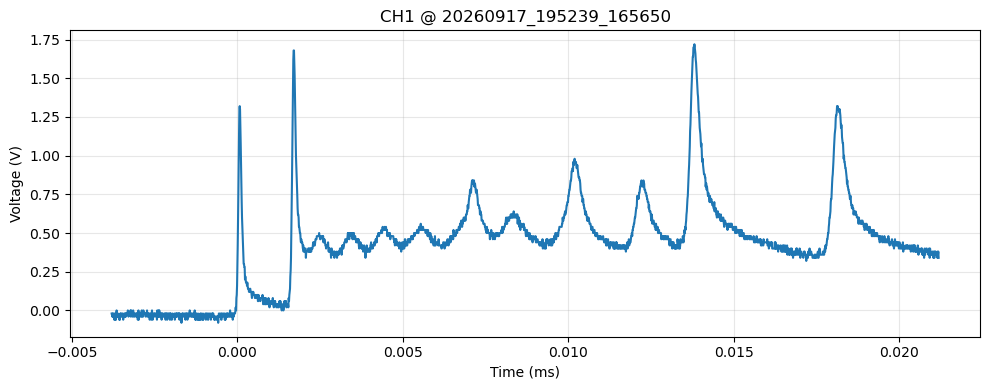

Saved:
  scope_data\CH1_20260917_195239_165650.csv
  scope_data\CH1_20260917_195239_165650.png


In [541]:
stamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

csv_path = SAVE_DIR / f"CH1_{stamp}.csv"
np.savetxt(csv_path, np.column_stack([t, v]),
           delimiter=",", header="time_s,voltage_V", comments="")

png_path = SAVE_DIR / f"CH1_{stamp}.png"
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t * 1e3, v)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (V)")
ax.set_title(f"CH1 @ {stamp}")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(png_path, dpi=150)
plt.show()

print("Saved:")
print(" ", csv_path)
print(" ", png_path)

In [542]:
scope.close()
rm.close()

In [543]:
# Estamos usando 450Hz en el chopper. 
# 19:21:46 estamos en 1.67A

# 19:30:08 cambiamos de corriente a 1.8A 

# a 19:34:31 pusimos 1.9A 

# a 19:39:09 pusimos 2.A -> CUrioso, el maximo no es el primero 

# a 19:45 pusimos 2.10 (creo que hubo una confusion antes)

# a 19:47 pusimos 2.20 

# a 19:49 pusimos 2.30

# a 19:50:10 pusimso 2.38


# a 19:51:45 pusimos 2A por las dudas 
